# ρ ODE Diagnostics for Rate and Probability Frameworks

This notebook studies the scalar active-link density equation with constant magnetization $m = m_0$.

We solve both frameworks:

$$
frac{d
ho}{dt} = frac{2
ho}{u} eft[ (u-1) eft( 1-frac{2
ho}{(1-m_0^2)} 
ight) - 1 
ight] - r
ho + r
ho_{athrm{reset}}
$$

$$
frac{d
ho}{dt} = (1-r)frac{2
ho}{u} eft[ (u-1) eft( 1-frac{2
ho}{(1-m_0^2)} 
ight) - 1 
ight] - r
ho + r
ho_{athrm{reset}}
$$

The notebook focuses on internal diagnostics:
- trajectories stay in $[0,1]$
- the right-hand side is close to zero at the final time
- equilibrium points are real and physically plausible
- the two frameworks can be solved and plotted side by side

In [79]:
using DifferentialEquations
using Plots
using Statistics
using Printf
using Graphs
using Random

project_root = isdir(joinpath(pwd(), "src")) ? pwd() : dirname(dirname(pwd()))
include(joinpath(project_root, "src", "VoterResetting.jl"))

default(size = (950, 520), linewidth = 2)
println("Julia ODE tools and VoterResetting loaded")

Julia ODE tools and VoterResetting loaded


In [80]:
function rho_terms(mu::Real, m0::Real)
    denominator = 1 - m0^2
    abs(denominator) > 1e-12 || throw(ArgumentError("abs(m0) must be smaller than 1 to avoid division by zero."))

    a = 2 * (mu - 2) / mu
    b = 4 * (mu - 1) / (mu * denominator)
    return Float64(a), Float64(b)
end

function rho_rhs_scalar(framework::Symbol, rho::Real, mu::Real, m0::Real, r::Real, rho_reset::Real)
    a, b = rho_terms(mu, m0)
    voter_term = a * rho - b * rho^2

    if framework === :rate
        return voter_term - r * rho + r * rho_reset
    elseif framework === :probability
        return (1 - r) * voter_term - r * rho + r * rho_reset
    else
        throw(ArgumentError("framework must be :rate or :probability"))
    end
end

function rho_rhs!(du, u, p, t)
    du[1] = rho_rhs_scalar(p.framework, u[1], p.mu, p.m0, p.r, p.rho_reset)
end

function solve_rho(framework::Symbol; mu::Real, m0::Real, r::Real, rho_reset::Real, rho_init::Real, tspan = (0.0, 120.0))
    params = (
        framework = framework,
        mu = Float64(mu),
        m0 = Float64(m0),
        r = Float64(r),
        rho_reset = Float64(rho_reset),
    )

    problem = ODEProblem(rho_rhs!, [Float64(rho_init)], tspan, params)
    return solve(problem, Tsit5(); reltol = 1e-10, abstol = 1e-10, saveat = range(tspan[1], tspan[2], length = 400))
end

function rho_equilibria(framework::Symbol; mu::Real, m0::Real, r::Real, rho_reset::Real)
    a, b = rho_terms(mu, m0)

    if framework === :rate
        A = b
        B = -(a - r)
        C = -(r * rho_reset)
    elseif framework === :probability
        A = b * (1 - r)
        B = -((a * (1 - r)) - r)
        C = -(r * rho_reset)
    else
        throw(ArgumentError("framework must be :rate or :probability"))
    end

    if abs(A) < 1e-14
        return sort([Float64(-C / B)])
    end

    discriminant = B^2 - 4 * A * C
    discriminant < 0 && return Float64[]

    root1 = (-B - sqrt(discriminant)) / (2 * A)
    root2 = (-B + sqrt(discriminant)) / (2 * A)
    return sort([Float64(root1), Float64(root2)])
end

rho_equilibria (generic function with 1 method)

In [81]:
# Example parameters
mu = 20
m0 = 0.25
rho_reset = (1 + m0) / 2
rho_init = 0.10
r = 0.15
tspan = (0.0, 20.0)

rate_sol = solve_rho(:rate; mu = mu, m0 = m0, r = r, rho_reset = rho_reset, rho_init = rho_init, tspan = tspan)
prob_sol = solve_rho(:probability; mu = mu, m0 = m0, r = r, rho_reset = rho_reset, rho_init = rho_init, tspan = tspan)

rate_eq = rho_equilibria(:rate; mu = mu, m0 = m0, r = r, rho_reset = rho_reset)
prob_eq = rho_equilibria(:probability; mu = mu, m0 = m0, r = r, rho_reset = rho_reset)

println("Example setup:")
@printf("  mu = %.0f\n", mu)
@printf("  m0 = %.3f\n", m0)
@printf("  rho_reset = %.3f\n", rho_reset)
@printf("  rho_init = %.3f\n", rho_init)
@printf("  r = %.3f\n", r)
println("  rate equilibria = $rate_eq")
println("  probability equilibria = $prob_eq")

Example setup:
  mu = 20
  m0 = 0.250
  rho_reset = 0.625
  rho_init = 0.100
  r = 0.150
  rate equilibria = [-0.0505427211025409, 0.4576150895235935]
  probability equilibria = [-0.05918844837194794, 0.4597302440375826]


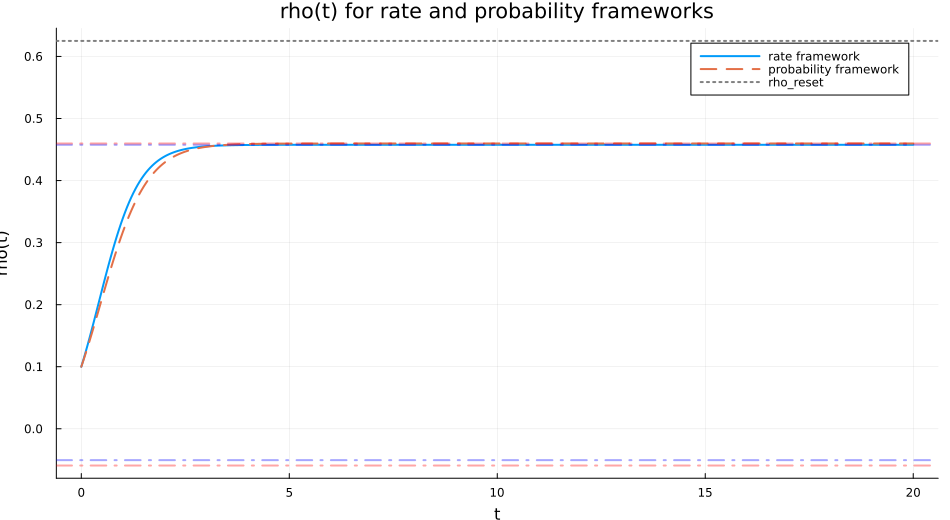

In [82]:
p = plot(
    rate_sol.t, rate_sol[1, :],
    label = "rate framework",
    xlabel = "t",
    ylabel = "rho(t)",
    title = "rho(t) for rate and probability frameworks",
)
plot!(p, prob_sol.t, prob_sol[1, :], label = "probability framework", linestyle = :dash)
hline!(p, [rho_reset], label = "rho_reset", linestyle = :dot, color = :gray)
for root in rate_eq
    hline!(p, [root], label = false, linestyle = :dashdot, color = :blue, alpha = 0.35)
end
for root in prob_eq
    hline!(p, [root], label = false, linestyle = :dashdot, color = :red, alpha = 0.35)
end
p

## Probability-Framework Trajectories

The next cell prints sampled trajectories for a few parameter choices in the probability framework only.

In [83]:
# Print sampled trajectories for several probability-framework parameter sets
trajectory_cases = [
    (mu = 6,  m0 = 0.00, r = 0.05, rho_init = 0.10),
    (mu = 6,  m0 = 0.50, r = 0.15, rho_init = 0.10),
    (mu = 20, m0 = 0.25, r = 0.15, rho_init = 0.10),
    (mu = 20, m0 = 0.80, r = 0.35, rho_init = 0.10),
]

sample_indices = [1, 80, 160, 240, 320, 400]

println("Probability-framework trajectories (sampled points)")
println(repeat("=", 72))

for case in trajectory_cases
    rho_reset_value = (1 + case.m0) / 2
    sol = solve_rho(
        :probability;
        mu = case.mu,
        m0 = case.m0,
        r = case.r,
        rho_reset = rho_reset_value,
        rho_init = case.rho_init,
        tspan = (0.0, 120.0),
    )

    println()
    @printf("mu=%d  m0=%.2f  r=%.2f  rho_init=%.2f  rho_reset=%.2f\n", case.mu, case.m0, case.r, case.rho_init, rho_reset_value)
    println("t       rho(t)")
    println(repeat("-", 18))

    for idx in sample_indices
        t_value = sol.t[idx]
        rho_value = sol[1, idx]
        @printf("%6.1f  %.6f\n", t_value, rho_value)
    end
end

println(repeat("=", 72))

Probability-framework trajectories (sampled points)

mu=6  m0=0.00  r=0.05  rho_init=0.10  rho_reset=0.50
t       rho(t)
------------------
   0.0  0.100000
  23.8  0.403763
  47.8  0.403763
  71.9  0.403763
  95.9  0.403763
 120.0  0.403763

mu=6  m0=0.50  r=0.15  rho_init=0.10  rho_reset=0.75
t       rho(t)
------------------
   0.0  0.100000
  23.8  0.346290
  47.8  0.346290
  71.9  0.346290
  95.9  0.346290
 120.0  0.346290

mu=20  m0=0.25  r=0.15  rho_init=0.10  rho_reset=0.62
t       rho(t)
------------------
   0.0  0.100000
  23.8  0.459730
  47.8  0.459730
  71.9  0.459730
  95.9  0.459730
 120.0  0.459730

mu=20  m0=0.80  r=0.35  rho_init=0.10  rho_reset=0.90
t       rho(t)
------------------
   0.0  0.100000
  23.8  0.282202
  47.8  0.282202
  71.9  0.282202
  95.9  0.282202
 120.0  0.282202


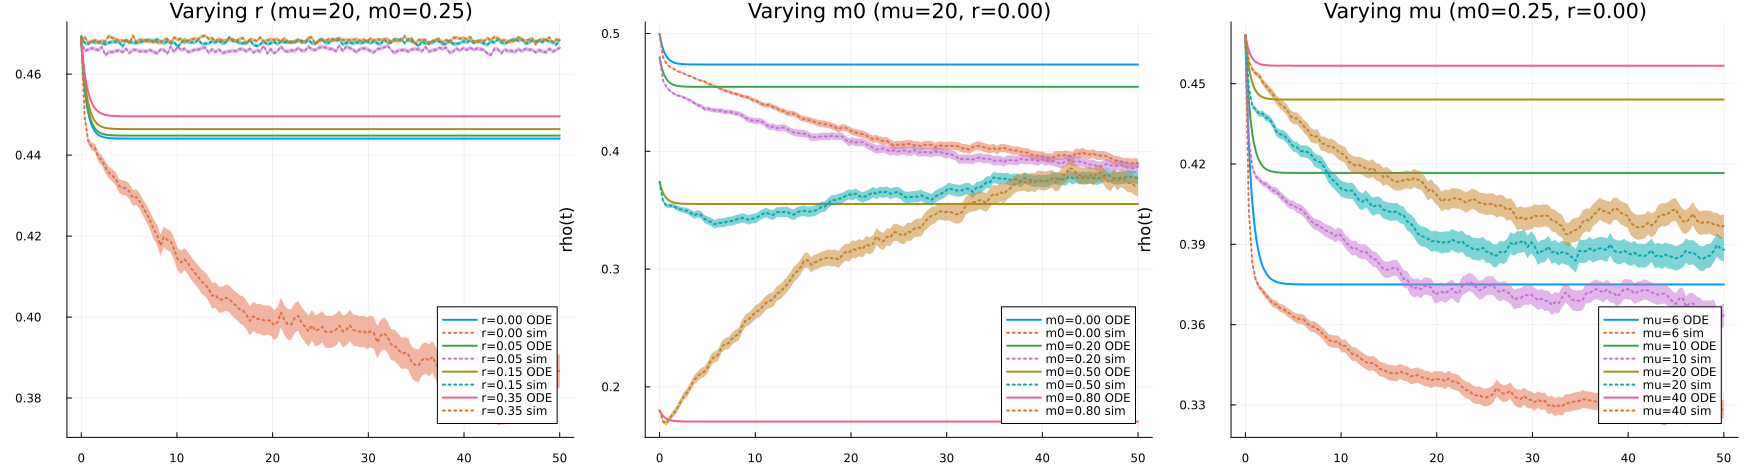

In [84]:
# Probability-framework trajectory plots with discrete-time VM simulation overlay
# Includes:
#   1) more realizations (larger nsamples) to reduce noise,
#   2) optional simulation time rescaling by a factor (default N).

function build_rrg_with_mu(N::Int, mu::Int)
    mu_eff = min(mu, N - 1)
    if isodd(N * mu_eff)
        mu_eff -= 1
    end
    mu_eff >= 2 || throw(ArgumentError("mu must be at least 2 after parity adjustment."))
    return random_regular_graph(N, mu_eff), mu_eff
end

function active_rho(cache, state)
    return length(VoterResetting.active_edge_ids_from_state(cache, state)) / length(cache.edge_u)
end

function estimate_reset_rho(cache, N::Int, m_reset::Real; ntrials::Int = 160)
    rho_values = Vector{Float64}(undef, ntrials)
    for trial in 1:ntrials
        reset_state = VoterResetting.random_spin_state(N, m_reset)
        rho_values[trial] = active_rho(cache, reset_state)
    end
    return mean(rho_values)
end

function simulate_rho_discrete_single(graph, cache, params::VoterResetting.ComplexParams, steps::AbstractVector{Int};
        reset::VoterResetting.AbstractResetProtocol)
    N = nv(graph)
    M = ne(graph)

    state = VoterResetting.random_spin_state(N, params.m0)
    active_list = VoterResetting.active_edge_ids_from_state(cache, state)
    pos_map = zeros(Int, M)
    VoterResetting.rebuild_active_structures!(active_list, pos_map, copy(active_list))

    samples = Vector{Float64}(undef, length(steps))
    t_idx = 1
    max_step = maximum(steps)

    for step in 1:max_step
        while t_idx <= length(steps) && steps[t_idx] <= step
            samples[t_idx] = isempty(active_list) ? 0.0 : (length(active_list) / M)
            t_idx += 1
        end

        if t_idx > length(steps)
            break
        end

        if rand() < params.r
            m_reset = VoterResetting.reset_target_magnetization(reset, params.m0)
            state .= VoterResetting.random_spin_state(N, m_reset)
            active_list = VoterResetting.active_edge_ids_from_state(cache, state)
            VoterResetting.rebuild_active_structures!(active_list, pos_map, copy(active_list))
        elseif !isempty(active_list)
            edge_id = active_list[rand(1:length(active_list))]
            u = cache.edge_u[edge_id]
            v = cache.edge_v[edge_id]
            flipped_node = rand(Bool) ? u : v
            state[flipped_node] = state[u == flipped_node ? v : u]
            VoterResetting.update_incident_edges!(active_list, pos_map, cache, state, flipped_node)
        end
    end

    final_rho = isempty(active_list) ? 0.0 : (length(active_list) / M)
    while t_idx <= length(steps)
        samples[t_idx] = final_rho
        t_idx += 1
    end

    return samples
end

function simulate_rho_discrete_ensemble(; N::Int, mu::Int, m0::Real, r::Real,
        steps::AbstractVector{Int}, nsamples::Int = 300, time_scale_factor::Real = 1.0)
    graph, mu_eff = build_rrg_with_mu(N, mu)
    cache = VoterResetting.build_graph_cache(graph)
    params = VoterResetting.ComplexParams(r, m0)
    reset = VoterResetting.delta_reset(m0)

    traces = Matrix{Float64}(undef, nsamples, length(steps))
    for sample_id in 1:nsamples
        traces[sample_id, :] .= simulate_rho_discrete_single(graph, cache, params, steps; reset = reset)
    end

    rho_init_sim = mean(traces[:, 1])
    rho_reset_sim = estimate_reset_rho(cache, N, m0)

    mean_trace = Vector{Float64}(undef, length(steps))
    sem_trace = Vector{Float64}(undef, length(steps))
    survivors = Vector{Int}(undef, length(steps))

    if iszero(r)
        # For r = 0, condition averages on trajectories that have not yet reached rho = 0.
        for j in eachindex(steps)
            alive = view(traces, :, j) .> 0.0
            survivors[j] = count(alive)
            if survivors[j] == 0
                mean_trace[j] = NaN
                sem_trace[j] = NaN
            else
                vals = traces[alive, j]
                mean_trace[j] = mean(vals)
                sem_trace[j] = survivors[j] > 1 ? (std(vals) / sqrt(survivors[j])) : 0.0
            end
        end
    else
        mean_trace .= vec(mean(traces; dims = 1))
        sem_trace .= vec(std(traces; dims = 1)) ./ sqrt(nsamples)
        survivors .= nsamples
    end

    return (
        times = Float64.(steps) ./ time_scale_factor,
        mean = mean_trace,
        sem = sem_trace,
        survivors = survivors,
        rho_init_sim = rho_init_sim,
        rho_reset_sim = rho_reset_sim,
        mu_eff = mu_eff,
    )
end

plot_cases = [
    (
        title = "Varying r (mu=20, m0=0.25)",
        cases = [
            (label = "r=0.00", mu = 20, m0 = 0.25, r = 0.00),
            (label = "r=0.05", mu = 20, m0 = 0.25, r = 0.05),
            (label = "r=0.15", mu = 20, m0 = 0.25, r = 0.15),
            (label = "r=0.35", mu = 20, m0 = 0.25, r = 0.35),
        ],
    ),
    (
        title = "Varying m0 (mu=20, r=0.00)",
        cases = [
            (label = "m0=0.00", mu = 20, m0 = 0.00, r = 0.00),
            (label = "m0=0.20", mu = 20, m0 = 0.20, r = 0.00),
            (label = "m0=0.50", mu = 20, m0 = 0.50, r = 0.00),
            (label = "m0=0.80", mu = 20, m0 = 0.80, r = 0.00),
        ],
    ),
    (
        title = "Varying mu (m0=0.25, r=0.00)",
        cases = [
            (label = "mu=6",  mu = 6,  m0 = 0.25, r = 0.00),
            (label = "mu=10", mu = 10, m0 = 0.25, r = 0.00),
            (label = "mu=20", mu = 20, m0 = 0.25, r = 0.00),
            (label = "mu=40", mu = 40, m0 = 0.25, r = 0.00),
        ],
    ),
]

function plot_probability_sweep(case_group; N = 600, tmax = 50.0, nsamples = 300,
        use_time_rescale = true, nobs = 140)
    plot_object = plot(title = case_group.title, xlabel = "t", ylabel = "rho(t)", legend = :bottomright)

    # If use_time_rescale=true, we assume 1 ODE time unit ~ N discrete VM updates.
    # Then simulation time is converted as t_sim = step / N.
    time_scale_factor = use_time_rescale ? Float64(N) : 1.0
    max_step = Int(round(tmax * time_scale_factor))
    obs_steps = unique(round.(Int, range(1, max_step, length = nobs)))

    for case in case_group.cases
        sim = simulate_rho_discrete_ensemble(
            N = N,
            mu = case.mu,
            m0 = case.m0,
            r = case.r,
            steps = obs_steps,
            nsamples = nsamples,
            time_scale_factor = time_scale_factor,
        )

        # ODE uses the same effective initial and reset rho as simulation.
        ode_solution = solve_rho(
            :probability;
            mu = case.mu,
            m0 = case.m0,
            r = case.r,
            rho_reset = sim.rho_reset_sim,
            rho_init = sim.rho_init_sim,
            tspan = (0.0, tmax),
        )

        plot!(plot_object, ode_solution.t, ode_solution[1, :], label = case.label * " ODE", linewidth = 2)
        plot!(plot_object, sim.times, sim.mean, ribbon = sim.sem, label = case.label * " sim", linestyle = :dot, linewidth = 2)
    end

    return plot_object
end

# Larger nsamples to reduce noise; simulation time is rescaled by N by default.
p_r = plot_probability_sweep(plot_cases[1]; nsamples = 640, use_time_rescale = true)
p_m0 = plot_probability_sweep(plot_cases[2]; nsamples = 640, use_time_rescale = true)
p_mu = plot_probability_sweep(plot_cases[3]; nsamples = 640, use_time_rescale = true)
plot(p_r, p_m0, p_mu, layout = (1, 3), size = (1750, 470))